In [8]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

image_paths = [
   # '/content/drive/My Drive/Colab Notebooks/D1_16.png',
   # '/content/drive/My Drive/Colab Notebooks/D2_16.png',
   # '/content/drive/My Drive/Colab Notebooks/D3_16.png',
    '/content/drive/My Drive/Colab Notebooks/D4_16.png',
   # '/content/drive/My Drive/Colab Notebooks/D5_16.png'
]

# MSE 계산 함수
def calculate_mse(original, restored):
    return np.mean((original - restored) ** 2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/content/drive/My Drive/Colab Notebooks/D1_16.png의 최대 픽셀 값: 44767
/content/drive/My Drive/Colab Notebooks/D2_16.png의 최대 픽셀 값: 10023
/content/drive/My Drive/Colab Notebooks/D3_16.png의 최대 픽셀 값: 3194
/content/drive/My Drive/Colab Notebooks/D4_16.png의 최대 픽셀 값: 28280
/content/drive/My Drive/Colab Notebooks/D5_16.png의 최대 픽셀 값: 16700


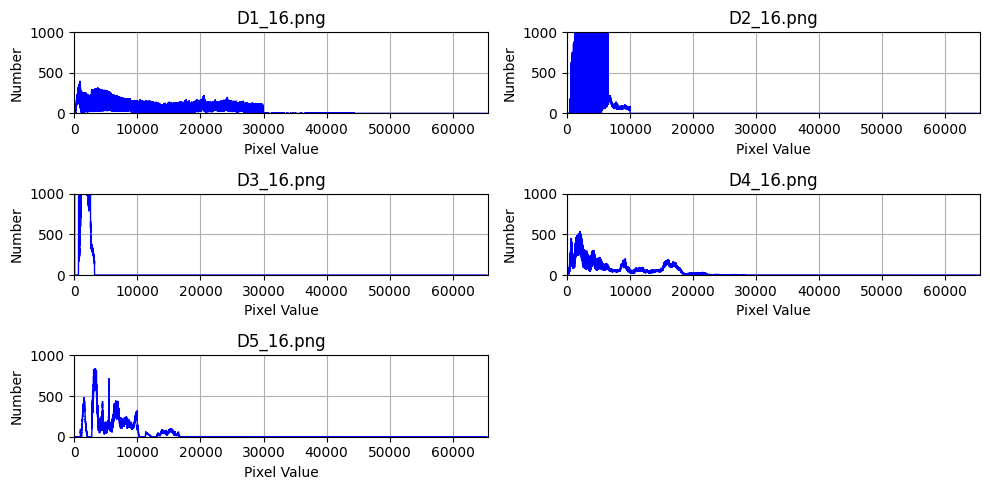

In [5]:
# 5개의 이미지 픽셀 분포를 히스토그램

plt.figure(figsize=(10, 5))  # 전체 크기 조정

for idx, image_path in enumerate(image_paths):
    # 이미지 불러오기
    depth_image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    max_pixel_value = np.max(depth_image)

    print(f"{image_path}의 최대 픽셀 값: {max_pixel_value}")

    # 각 이미지의 히스토그램 서브플롯 생성
    plt.subplot(3, 2, idx + 1)
    plt.hist(depth_image.ravel(), bins=65536, range=(0, 65535), color='blue', histtype='step')
    plt.ylim(0, 1000)
    plt.title(f'D{idx + 1}_16.png')
    plt.xlabel('Pixel Value')
    plt.ylabel('Number')
    plt.xlim([0, 65535])
    plt.grid(True)

# 레이아웃 정리 및 표시
plt.tight_layout()
plt.show()


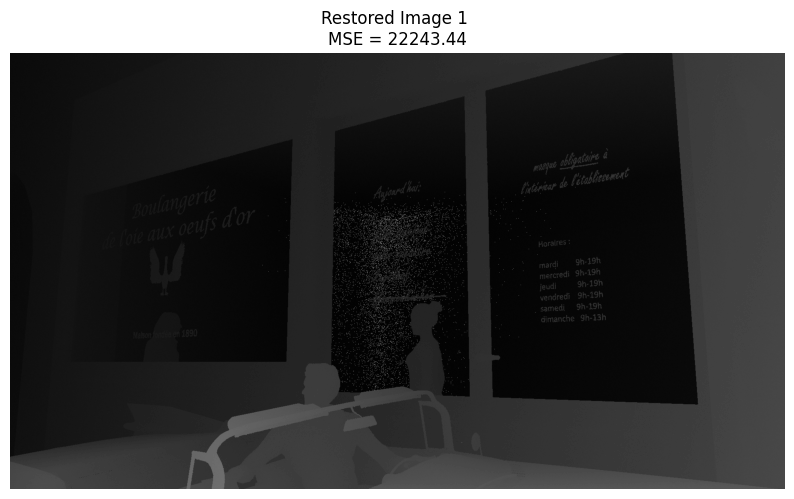

In [15]:
def map_to_rgb(value):
    if 0 <= value < 256:
        return (255, value, 0)                    #(255, 0~255, 0)
    elif 256 <= value < 512:
        return (255 - (value - 256), 255, 0)      #(255~0, 255, 0)
    elif 512 <= value < 768:
        return (0, 255, value - 512)              #(0, 255, 0~255)
    elif 768 <= value < 1024:
        return (0, 255 - (value - 768), 255)      #(0, 255~0, 255)
    elif 1024 <= value < 1280:
        return (value - 1024, 0, 255)             #(0~255, 0, 255)
    elif 1280 <= value < 1536:
        return (255, 0, 255 - (value - 1280))     #(255, 0, 255~0)

def map_to_value(r, g, b):

    #추가된 코드
    min_val = min(r, g, b)
    max_val = max(r, g, b)
    if r == max_val: r = 255
    elif r == min_val: r = 0

    if g == max_val: g = 255
    elif g == min_val: g = 0

    if b == max_val: b = 255
    elif b == min_val: b = 0

    # 기존 조건들
    if r == 255 and 0 <= g < 256 and b == 0:
        return g
    elif 0 <= r < 256 and g == 255 and b == 0:
        return 256 + (255 - r)
    elif r == 0 and g == 255 and 0 <= b < 256:
        return 512 + b
    elif r == 0 and 0 <= g < 256 and b == 255:
        return 768 + (255 - g)
    elif 0 <= r < 256 and g == 0 and b == 255:
        return 1024 + r
    elif r == 255 and g == 0 and 0 <= b < 256:
        return 1280 + (255 - b)

    else:
        result = None  # 모든 조건에 맞지 않는 경우



# 결과 이미지 저장 리스트
results = []

for image_path in image_paths:
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)                     # 원본 이미지 불러오기
    normalized_image = (image /44767 * 1535).astype(np.uint16)
    rgb_image = np.zeros((*normalized_image.shape, 3), dtype=np.uint8)       # RGB 이미지 저장공간
    restored_image = np.zeros(normalized_image.shape, dtype=np.uint16)       # 복원 이미지 저장공간

    #원본에서 RGB로 변환
    for i in range(normalized_image.shape[0]):
        for j in range(normalized_image.shape[1]):
            rgb_image[i, j] = map_to_rgb(normalized_image[i, j])

    #Gaussian 노이즈 추가
    noise = np.random.normal(0, 10, rgb_image.shape).astype(np.int16)        # 표준편차 설정
    noisy_rgb_image = np.clip(rgb_image.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    #JPEG 압축
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 90]                       # QP 설정
    _, compressed_img = cv2.imencode('.jpg', rgb_image, encode_param)        # JPEG로 압축
    decoded_img = cv2.imdecode(compressed_img, cv2.IMREAD_UNCHANGED)         # 다시 복원

    #RGB 이미지를 다시 원본 16비트 값으로 복원
    for i in range(decoded_img.shape[0]):
        for j in range(decoded_img.shape[1]):
            r, g, b = noisy_rgb_image[i, j]
            restored_image[i, j] = map_to_value(r, g, b)

    restored_image = (restored_image / 1535 * 44767).astype(np.uint16)       # 복원 이미지 16비트로 설정
    mse_value = calculate_mse(image, restored_image)                         # MSE 계산
    results.append((restored_image, mse_value))                              # 리스트에 원본, 복원된 이미지 저장

# 시각화
plt.figure(figsize=(10, 20))

for idx, (restored, mse) in enumerate(results):

    plt.subplot(len(results), 1, idx + 1)
    plt.title(f'Restored Image {idx + 1} \nMSE = {mse:.2f}')
    plt.imshow(restored, cmap='gray', vmin=0, vmax=65535)
    plt.axis('off')

plt.show()
